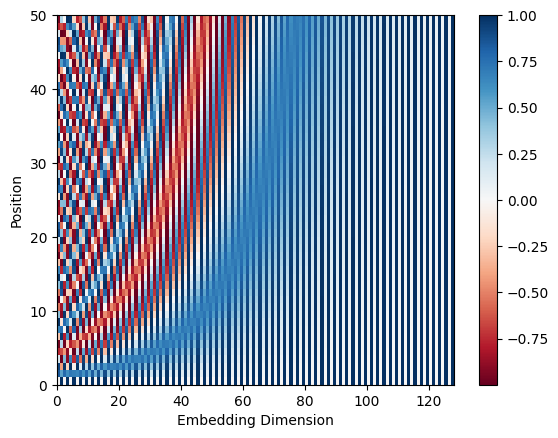

In [ ]:
# 위치 인코딩 계산 과정
import math
import torch
from torch import nn
from matplotlib import pyplot as plt

class PositionalEncoding(nn.Module):
  def __init__(self, d_model, max_len, dropout=0.1):
    super().__init__()
    self.dropout = nn.Dropout(p=dropout)
    position = torch.arange(max_len).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, d_model, 2)*(-math.log(1000.0)/d_model)
    )
    pe = torch.zeros(max_len, 1, d_model)
    pe[:,0,0::2] = torch.sin(position*div_term)
    pe[:,0,1::2] = torch.cos(position*div_term)
    self.register_buffer("pe", pe)
  def forward(self, x):
    x = x+self.pe[: x.size(0)]
    return self.dropout(x)
encoding = PositionalEncoding(d_model=128, max_len=50)

plt.pcolormesh(encoding.pe.numpy().squeeze(), cmap="RdBu")
plt.xlabel("Embedding Dimension")
plt.xlim((0,128))
plt.ylabel("Position")
plt.colorbar()
plt.show()

In [ ]:
# 1. 기존 충돌나는 라이브러리 강제 삭제
!pip uninstall -y torch torchtext

# 2. 서로 호환되는 '짝꿍 버전'으로 재설치 (Torch 2.3.1 + TorchText 0.18.0)
!pip install torch==2.3.1 torchtext==0.18.0

Found existing installation: torch 2.3.1
Uninstalling torch-2.3.1:
  Successfully uninstalled torch-2.3.1
Found existing installation: torchtext 0.18.0
Uninstalling torchtext-0.18.0:
  Successfully uninstalled torchtext-0.18.0
  Using cached torch-2.3.1-cp312-cp312-manylinux1_x86_64.whl.metadata (26 kB)
  Using cached torchtext-0.18.0-cp312-cp312-manylinux1_x86_64.whl.metadata (7.9 kB)
Using cached torch-2.3.1-cp312-cp312-manylinux1_x86_64.whl (779.1 MB)
Using cached torchtext-0.18.0-cp312-cp312-manylinux1_x86_64.whl (2.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.9.0+cu126 requires torch==2.9.0, but you have torch 2.3.1 which is incompatible.
torchtune 0.6.1 requires torchdata==0.11.0, but you have torchdata 0.7.1 which is incompatible.
torchvision 0.24.0+cu126 requires torch==2.9.0, but you have torch 2.3.1 which is incompatible.


In [ ]:
# 독일어 모델 다운로드
!python -m spacy download de_core_news_sm

# 영어 모델 다운로드
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 57.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 127.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
from torchtext.datasets import Multi30k
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator

Multi30k.urls = [
    "https://raw.githubusercontent.com/neychev/small_DL_repo/master/datasets/Multi30k/training.tar.gz",
    "https://raw.githubusercontent.com/neychev/small_DL_repo/master/datasets/Multi30k/validation.tar.gz",
    "https://raw.githubusercontent.com/neychev/small_DL_repo/master/datasets/Multi30k/mmt_task1_test2016.tar.gz"
]
Multi30k.splits = ["train", "val", "test"]

def generate_tokens(text_iter, language):
    language_index = {SRC_LANGUAGE: 0, TGT_LANGUAGE: 1}

    for text in text_iter:
        yield token_transform[language](text[language_index[language]])


SRC_LANGUAGE = "de"
TGT_LANGUAGE = "en"
UNK_IDX, PAD_IDX, BOS_IDX, EOS_IDX = 0, 1, 2, 3
special_symbols = ["<unk>", "<pad>", "<bos>", "<eos>"]

token_transform = {
    SRC_LANGUAGE: get_tokenizer("spacy", language="de_core_news_sm"),
    TGT_LANGUAGE: get_tokenizer("spacy", language="en_core_web_sm"),
}
print("Token Transform:")
print(token_transform)

vocab_transform = {}
for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
    train_iter = Multi30k(split="train", language_pair=(SRC_LANGUAGE, TGT_LANGUAGE))
    vocab_transform[language] = build_vocab_from_iterator(
        generate_tokens(train_iter, language),
        min_freq=1,
        specials=special_symbols,
        special_first=True,
    )

for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
    vocab_transform[language].set_default_index(UNK_IDX)

print("Vocab Transform:")
print(vocab_transform)

Token Transform:
{'de': functools.partial(<function _spacy_tokenize at 0x78e5902cb4c0>, spacy=<spacy.lang.de.German object at 0x78e4cdf12bd0>), 'en': functools.partial(<function _spacy_tokenize at 0x78e5902cb4c0>, spacy=<spacy.lang.en.English object at 0x78e3e543f2c0>)}
Vocab Transform:
{'de': Vocab(), 'en': Vocab()}


# 트랜스포머 모델 구축

In [ ]:
# 트랜스포머 모델 구성
import math
import torch
from torch import nn

class PositionalEncoding(nn.Module):
  def __init__(self, d_model, max_len, dropout=0.1):
    super().__init__()
    self.dropout = nn.Dropout(p=dropout)
    position=torch.arange(max_len).unsqueeze(1)
    div_term=torch.exp(
        torch.arange(0, d_model, 2)*(-math.log(10000.0)/d_model)
    )
    pe = torch.zeros(max_len, 1, d_model)
    pe[:, 0, 0::2] = torch.sin(position*div_term)
    pe[:, 0, 1::2] = torch.cos(position*div_term)
    self.register_buffer("pe", pe)
  def forward(self, x):
    x = x+self.pe[: x.size(0)]
    return self.dropout(x)

class TokenEmbedding(nn.Module):
  def __init__(self, vocab_size, emb_size):
    super().__init__()
    # padding_idx를 추가하여 패딩 토큰은 임베딩에서 무시되도록 수정
    self.embedding = nn.Embedding(vocab_size, emb_size, padding_idx=PAD_IDX)
    self.emb_size=emb_size
  def forward(self, tokens):
    return self.embedding(tokens.long())*math.sqrt(self.emb_size)

# Seq2SeqTransformer: 소스와 타깃 데이터의 어휘 사전 크기를 입력받아 트랜스포머 임베딩 크기로 변환
class Seq2SeqTransformer(nn.Module): # TokenEmbedding클래스로 소스와 입력 데이터를 입력 임베딩으로 변환하여 src_tok_emb과 tgt_'을 생성
  def __init__(
      self,
      num_encoder_layers,
      num_decoder_layers,
      emb_size,
      max_len,
      nhead,
      src_vocab_size,
      tgt_vocab_size,
      dim_feedforward,
      dropout=0.1,
  ):
    super().__init__()
    self.src_tok_emb = TokenEmbedding(src_vocab_size, emb_size)
    self.tgt_tok_emb = TokenEmbedding(tgt_vocab_size, emb_size)
    self.positional_encoding = PositionalEncoding(
        d_model=emb_size, max_len=max_len, dropout=dropout
    )
    # self.transformer: 트랜스포머 블록, 파이토치에서 제공하는 트랜스포머 클래스를 적용한다.
    self.transformer = nn.Transformer(
        d_model=emb_size,
        nhead=nhead,
        num_encoder_layers=num_encoder_layers,
        num_decoder_layers=num_decoder_layers,
        dim_feedforward=dim_feedforward,
        dropout=dropout,
    )
    # 순방향 메서드 마지막에 적용되는 generator는 마지막 트랜스포머 디코더 블록에서 산출되는 벡터를 선형변환해 어휘 사전에 대한 로짓 생성
    self.generator=nn.Linear(emb_size, tgt_vocab_size)
  def forward(
      self,
      src,
      trg,
      src_mask,
      tgt_mask,
      src_padding_mask,
      tgt_padding_mask,
      memory_key_padding_mask,
  ):
      src_emb = self.positional_encoding(self.src_tok_emb(src))
      # BUG FIX: target embedding should use trg tensor, not src tensor
      tgt_emb = self.positional_encoding(self.tgt_tok_emb(trg))
      outs = self.transformer(
          src=src_emb,
          tgt=tgt_emb,
          src_mask=src_mask,
          tgt_mask=tgt_mask,
          src_key_padding_mask=src_padding_mask,
          tgt_key_padding_mask=tgt_padding_mask,
          memory_key_padding_mask=memory_key_padding_mask
      )
      return self.generator(outs)
  def encode(self, src, src_mask):
    return self.transformer.encoder(
        self.positional_encoding(self.src_tok_emb(src)), src_mask
    )
  def decode(self, tgt, memory, tgt_mask):
    return self.transformer.decoder(
        self.positional_encoding(self.tgt_tok_emb(tgt)), memory, tgt_mask
    )

In [ ]:
# 트랜스포머 클래스
transformer = torch.nn.Transformer(
    d_model=512,
    nhead=8,
    num_encoder_layers=6,
    num_decoder_layers=6,
    dim_feedforward=2048,
    dropout=0.1,
    activation=torch.nn.functional.relu,
    layer_norm_eps=1e-05,
)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:306: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [ ]:
from torch import optim
# 트랜스포머 모델 구조

BATCH_SIZE = 128
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = Seq2SeqTransformer(
    num_encoder_layers=3, # 인코더 디코더 각각 세 개의 계층으로 구성
    num_decoder_layers=3,
    emb_size=512,
    max_len=512,
    nhead=8,
    src_vocab_size=len(vocab_transform[SRC_LANGUAGE]),
    tgt_vocab_size=len(vocab_transform[TGT_LANGUAGE]),
    dim_feedforward=512,
).to(DEVICE)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX).to(DEVICE)
optimizer = optim.Adam(model.parameters())

for main_name, main_module in model.named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("└", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("│  └", ssub_name)
            for sssub_name, sssub_module in ssub_module.named_children():
                print("│  │  └", sssub_name)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:306: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


src_tok_emb
└ embedding
tgt_tok_emb
└ embedding
positional_encoding
└ dropout
transformer
└ encoder
│  └ layers
│  │  └ 0
│  │  └ 1
│  │  └ 2
│  └ norm
└ decoder
│  └ layers
│  │  └ 0
│  │  └ 1
│  │  └ 2
│  └ norm
generator


- 인코더와 디코더 각각 세 개 (0,1,2)의 계층으로 구성

In [ ]:
# 배치 데이터 생성
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence # pad_sequence 함수: 소스와 타깃 시퀀스 패딩
# sequential_transforms 함수: 여러 개의 전처리 함수를 인자로 받아 이를 차례로 적용하는 함수
def sequential_transforms(*transforms):
    def func(txt_input):
        for transform in transforms:
            txt_input = transform(txt_input)
        return txt_input
    return func

def input_transform(token_ids):
    return torch.cat(
        (torch.tensor([BOS_IDX]), torch.tensor(token_ids), torch.tensor([EOS_IDX]))
    )
# collator 함수: 배치 단위로 데이터 처리
def collator(batch):
    src_batch, tgt_batch = [], []
    for src_sample, tgt_sample in batch:
        src_batch.append(text_transform[SRC_LANGUAGE](src_sample.rstrip("\n"))) # rstrip으로 문자열 끝의 개행문자 제거
        tgt_batch.append(text_transform[TGT_LANGUAGE](tgt_sample.rstrip("\n")))

    src_batch = pad_sequence(src_batch, padding_value=PAD_IDX)
    tgt_batch = pad_sequence(tgt_batch, padding_value=PAD_IDX)
    return src_batch, tgt_batch


text_transform = {}
for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
    text_transform[language] = sequential_transforms(
        token_transform[language], vocab_transform[language], input_transform
    ) # toekn_transform: 문장 토큰화 vocab_transform: 토큰 인덱스화 input_transform: 특수토큰 할당
# data_iter 변수에 텍스트 데이터셋 불러옴
data_iter = Multi30k(split="valid", language_pair=(SRC_LANGUAGE, TGT_LANGUAGE))
dataloader = DataLoader(data_iter, batch_size=BATCH_SIZE, collate_fn=collator)
source_tensor, target_tensor = next(iter(dataloader))

print("(source, target):")
print(next(iter(data_iter)))

print("source_batch:", source_tensor.shape)
print(source_tensor)

print("target_batch:", target_tensor.shape)
print(target_tensor)

(source, target):
('Eine Gruppe von Männern lädt Baumwolle auf einen Lastwagen', 'A group of men are loading cotton onto a truck')
source_batch: torch.Size([35, 128])
tensor([[   2,    2,    2,  ...,    2,    2,    2],
        [  14,    5,    5,  ...,    5,   21,    5],
        [  38,   12,   35,  ...,   12, 1750,   69],
        ...,
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1]])
target_batch: torch.Size([30, 128])
tensor([[   2,    2,    2,  ...,    2,    2,    2],
        [   6,    6,    6,  ...,  250,   19,    6],
        [  39,   12,   35,  ...,   12, 3254,   61],
        ...,
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1]])


In [ ]:
# 어텐션 마스크 생성

# 마스크 생성 함수: 입력으로 정수 s를 받아 sxs 크기의 마스크 생성
def generate_square_subsequent_mask(s):
    mask = (torch.triu(torch.ones((s, s), device=DEVICE)) == 1).transpose(0, 1) # torch.triu : 상삼각행렬 생성 함수
    mask = (
        mask.float()
        .masked_fill(mask == 0, float("-inf"))
        .masked_fill(mask == 1, float(0.0))
    )
    return mask

# 패딩 마스크 생성 함수: 시퀀스를 입력받아 길이를 계산하고 마스크 생성 함수로 타깃 시퀀스의 마스크를 생성
def create_mask(src, tgt):
    src_seq_len = src.shape[0]
    tgt_seq_len = tgt.shape[0]

    tgt_mask = generate_square_subsequent_mask(tgt_seq_len) # [쿼리 시퀀스 길이, 키 시퀀스 길이]의 형태, 현재 위치 이전의 토큰들만 참조
    src_mask = torch.zeros((src_seq_len, src_seq_len), device=DEVICE).type(torch.bool) # src_mask : 셀프 어텐션 과정에서 참조되는 소스 데이터의 시퀀스 범위를 나타냄

    # _padding_mask : 소스 배치 데이터에서 텍스트 토큰의 존재 여부
    src_padding_mask = (src == PAD_IDX).transpose(0, 1)
    tgt_padding_mask = (tgt == PAD_IDX).transpose(0, 1)
    return src_mask, tgt_mask, src_padding_mask, tgt_padding_mask


target_input = target_tensor[:-1, :]
target_out = target_tensor[1:, :]

source_mask, target_mask, source_padding_mask, target_padding_mask = create_mask(
    source_tensor, target_input
)

print("source_mask:", source_mask.shape)
print(source_mask)
print("target_mask:", target_mask.shape)
print(target_mask)
print("source_padding_mask:", source_padding_mask.shape)
print(source_padding_mask)
print("target_padding_mask:", target_padding_mask.shape)
print(target_padding_mask)

source_mask: torch.Size([35, 35])
tensor([[False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        ...,
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False]], device='cuda:0')
target_mask: torch.Size([29, 29])
tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
         -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
         -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
         -inf, -inf, -inf,

In [ ]:
# 모델 학습 및 평가

# run 함수: 소스와 타깃 데이터를 입력받아 collator로 문장을 토큰화하고 인덱스로 변환
def run(model, optimizer, criterion, split):
    model.train() if split == "train" else model.eval()
    data_iter = Multi30k(split=split, language_pair=(SRC_LANGUAGE, TGT_LANGUAGE))
    dataloader = DataLoader(data_iter, batch_size=BATCH_SIZE, collate_fn=collator)

    losses = 0
    for source_batch, target_batch in dataloader:
        source_batch = source_batch.to(DEVICE)
        target_batch = target_batch.to(DEVICE)

        target_input = target_batch[:-1, :]
        target_output = target_batch[1:, :]

        # create_mask: 트랜스포머 모델에 필요한 입력 패딩 마스크와 어텐션 마스크 생성
        # -> 타깃 시퀀스의 다음 토큰 예측에 활용
        src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(
            source_batch, target_input
        )

        logits = model(
            src=source_batch,
            trg=target_input,
            src_mask=src_mask,
            tgt_mask=tgt_mask,
            src_padding_mask=src_padding_mask,
            tgt_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask,
        )

        optimizer.zero_grad()
        loss = criterion(logits.reshape(-1, logits.shape[-1]), target_output.reshape(-1))
        if split == "train":
            loss.backward()
            optimizer.step()
        losses += loss.item()

    return losses / len(list(dataloader))


for epoch in range(5):
    train_loss = run(model, optimizer, criterion, "train")
    val_loss = run(model, optimizer, criterion, "valid")
    print(f"Epoch: {epoch+1}, Train loss: {train_loss:.3f}, Val loss: {val_loss:.3f}")

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:5137: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Epoch: 1, Train loss: 4.732, Val loss: 4.049
Epoch: 2, Train loss: 3.772, Val loss: 3.628
Epoch: 3, Train loss: 3.466, Val loss: 3.533
Epoch: 4, Train loss: 3.298, Val loss: 3.492
Epoch: 5, Train loss: 3.165, Val loss: 3.478


In [ ]:
# 트랜스포머 모델 번역 결과

# 모델 번역 방식 : 그리드 디코딩(Greedy decoding) 방식
# 현재까지 예측된 토큰들을 이용해 다음 토큰 예측
def greedy_decode(model, source_tensor, source_mask, max_len, start_symbol):
    source_tensor = source_tensor.to(DEVICE)
    source_mask = source_mask.to(DEVICE)

    memory = model.encode(source_tensor, source_mask)
    ys = torch.ones(1, 1).fill_(start_symbol).type(torch.long).to(DEVICE)
    for i in range(max_len - 1):
        memory = memory.to(DEVICE)
        target_mask = generate_square_subsequent_mask(ys.size(0))
        target_mask = target_mask.type(torch.bool).to(DEVICE)

        out = model.decode(ys, memory, target_mask) # out은 [토큰 개수, 배치 크기, 확률]의 형태
        out = out.transpose(0, 1) # transpose를 이용해 [배치 크기, 토큰 개수, 확률]의 형태로 반환
        prob = model.generator(out[:, -1]) # 슬라이싱해 [배치 크기, 확률] 로 만든다.
        _, next_word = torch.max(prob, dim=1) # 이후 가장 확률의 높은 인덱스를 찾는다
        next_word = next_word.item()

        ys = torch.cat(
            [ys, torch.ones(1, 1).type_as(source_tensor.data).fill_(next_word)], dim=0
        )
        if next_word == EOS_IDX:
            break
    return ys


def translate(model, source_sentence):
    model.eval()
    source_tensor = text_transform[SRC_LANGUAGE](source_sentence).view(-1, 1)
    num_tokens = source_tensor.shape[0]
    src_mask = (torch.zeros(num_tokens, num_tokens)).type(torch.bool)
    tgt_tokens = greedy_decode(
        model, source_tensor, src_mask, max_len=num_tokens + 5, start_symbol=BOS_IDX
    ).flatten()
    output = vocab_transform[TGT_LANGUAGE].lookup_tokens(list(tgt_tokens.cpu().numpy()))[1:-1] # lookup함수를 통해 텍스트로 변환
    return " ".join(output)


output_oov = translate(model, "Eine Gruppe von Menschen steht vor einem Iglu .")
output = translate(model, "Eine Gruppe von Menschen steht vor einem Gebäude .")
print(output_oov)
print(output)

A group of people are standing in a room .
A group of people are standing in a room .


## 모델 번역 방식 - 그리드 디코딩 방식
- 디코더 네트워크가 생성한 확률 분포에서 가장 높은 확률을 가지는 단어를 선택하는 방법
## 모델 추론 방식
- 디코더에 참조되는 마지막 인코드 트랜스포머 블록의 벡터, 타깃 데이터의 입력, 타깃 마스크를 사용